Classes: ['adware', 'backdoor', 'benign', 'downloader', 'spyware', 'trojan', 'virus', 'worm']
Number of classes: 8

TEST SET PERFORMANCE:
Overall Accuracy: 0.9697 (96.97%)
Average Confidence: 0.9610

Per-Class Accuracy:
  adware         :  94.50% | Confidence: 0.969 | Samples:  200
  backdoor       :  82.61% | Confidence: 0.835 | Samples:   69
  benign         :  98.03% | Confidence: 0.948 | Samples:  864
  downloader     : 100.00% | Confidence: 1.000 | Samples:  250
  spyware        :  93.68% | Confidence: 0.966 | Samples:   95
  trojan         :  95.52% | Confidence: 0.957 | Samples:  357
  virus          :  99.17% | Confidence: 0.995 | Samples:  240
  worm           :  97.79% | Confidence: 0.972 | Samples:  136


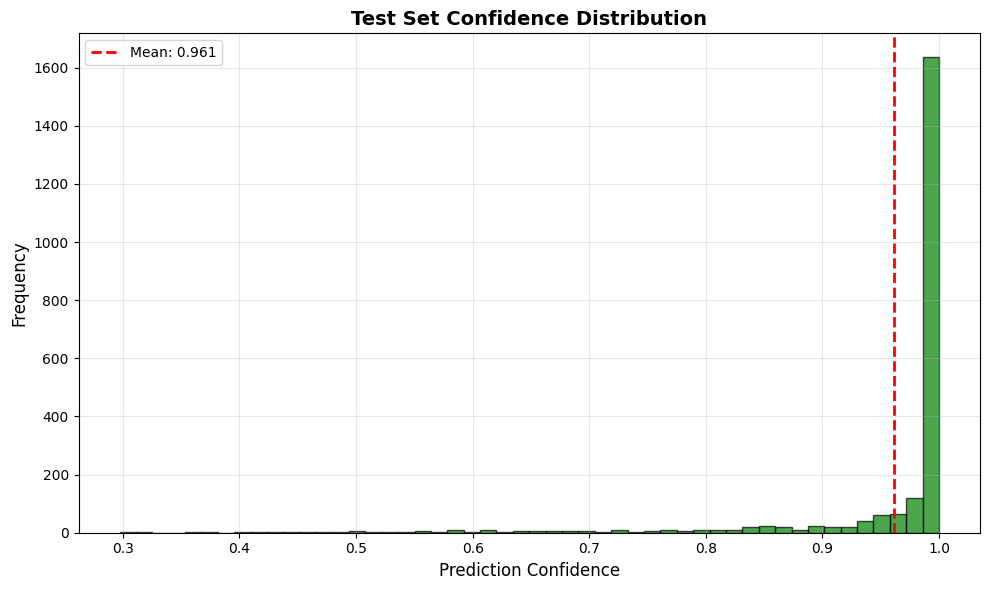


CONFIDENCE ANALYSIS:
Predictions >99% confident: 70.92%
Predictions >95% confident: 84.03%
Predictions <80% confident: 6.38%

⚠️  MODEL IS VERY OVERCONFIDENT - Likely overfitted!


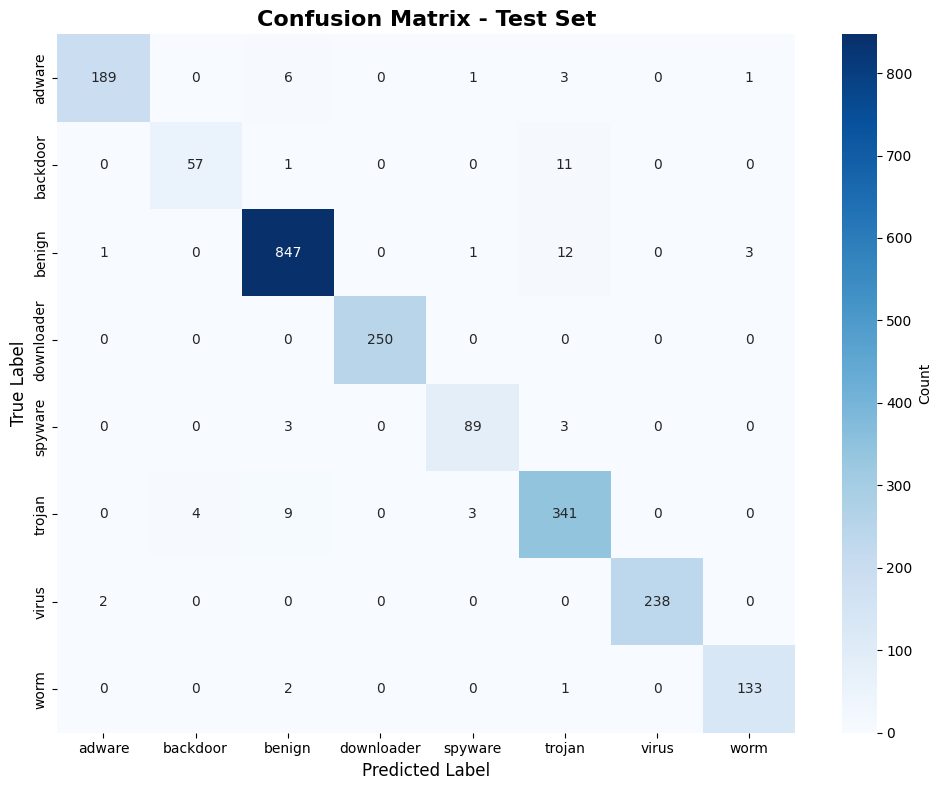


TEST SET CLASS DISTRIBUTION:

Class                Count   Percentage
----------------------------------------
adware                 200        9.05%
backdoor                69        3.12%
benign                 864       39.08%
downloader             250       11.31%
spyware                 95        4.30%
trojan                 357       16.15%
virus                  240       10.85%
worm                   136        6.15%

DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      adware     0.9844    0.9450    0.9643       200
    backdoor     0.9344    0.8261    0.8769        69
      benign     0.9758    0.9803    0.9781       864
  downloader     1.0000    1.0000    1.0000       250
     spyware     0.9468    0.9368    0.9418        95
      trojan     0.9191    0.9552    0.9368       357
       virus     1.0000    0.9917    0.9958       240
        worm     0.9708    0.9779    0.9744       136

    accuracy                         0.9697    

In [3]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# =========================
# Configuration
# =========================
DATA_PATH = r"C:\Users\lenovo LOQ\PFA2\Sorted"
BATCH_SIZE = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# Load Data (TEST ONLY)
# =========================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Only load test data since train is not available
test_dataset = datasets.ImageFolder(root=os.path.join(DATA_PATH, "test"), transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# =========================
# Load Model
# =========================
model_path = r"C:\Users\lenovo LOQ\PFA2\malware_classifier.pth"
model = torch.jit.load(model_path, map_location=device)
model.eval()
model.to(device)

print(f"Classes: {test_dataset.classes}")
print(f"Number of classes: {len(test_dataset.classes)}\n")

# =========================
# DIAGNOSTIC 1: Test Set Performance
# =========================
all_preds = []
all_labels = []
all_confidences = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        max_probs, _ = probs.max(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_confidences.extend(max_probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_confidences = np.array(all_confidences)

overall_acc = (all_preds == all_labels).mean()
avg_confidence = all_confidences.mean()

print(f"{'='*60}")
print(f"TEST SET PERFORMANCE:")
print(f"{'='*60}")
print(f"Overall Accuracy: {overall_acc:.4f} ({overall_acc*100:.2f}%)")
print(f"Average Confidence: {avg_confidence:.4f}")
print(f"\nPer-Class Accuracy:")

for i, class_name in enumerate(test_dataset.classes):
    mask = all_labels == i
    if mask.sum() > 0:
        class_acc = (all_preds[mask] == i).mean()
        class_conf = all_confidences[mask].mean()
        num_samples = mask.sum()
        print(f"  {class_name:15s}: {class_acc*100:6.2f}% | Confidence: {class_conf:.3f} | Samples: {num_samples:4d}")

# =========================
# DIAGNOSTIC 2: Confidence Distribution
# =========================
plt.figure(figsize=(10, 6))
plt.hist(all_confidences, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.axvline(avg_confidence, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {avg_confidence:.3f}')
plt.xlabel('Prediction Confidence', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Test Set Confidence Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"CONFIDENCE ANALYSIS:")
print(f"{'='*60}")
print(f"Predictions >99% confident: {(all_confidences > 0.99).mean()*100:.2f}%")
print(f"Predictions >95% confident: {(all_confidences > 0.95).mean()*100:.2f}%")
print(f"Predictions <80% confident: {(all_confidences < 0.80).mean()*100:.2f}%")

if (all_confidences > 0.99).mean() > 0.7:
    print("\n⚠️  MODEL IS VERY OVERCONFIDENT - Likely overfitted!")
elif (all_confidences > 0.95).mean() > 0.8:
    print("\n⚠️  MODEL IS OVERCONFIDENT - Possible overfitting")

# =========================
# DIAGNOSTIC 3: Confusion Matrix
# =========================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# =========================
# DIAGNOSTIC 4: Class Distribution
# =========================
print(f"\n{'='*60}")
print(f"TEST SET CLASS DISTRIBUTION:")
print(f"{'='*60}")

test_class_counts = {}
for _, label in test_dataset:
    class_name = test_dataset.classes[label]
    test_class_counts[class_name] = test_class_counts.get(class_name, 0) + 1

test_total = len(test_dataset)

print(f"\n{'Class':<15} {'Count':>10} {'Percentage':>12}")
print("-" * 40)
for class_name in sorted(test_class_counts.keys()):
    count = test_class_counts[class_name]
    pct = count / test_total * 100
    print(f"{class_name:<15} {count:>10} {pct:>11.2f}%")

# =========================
# DIAGNOSTIC 5: Classification Report
# =========================
print(f"\n{'='*60}")
print(f"DETAILED CLASSIFICATION REPORT:")
print(f"{'='*60}")
print(classification_report(all_labels, all_preds, 
                          target_names=test_dataset.classes, 
                          digits=4))

# =========================
# DIAGNOSTIC 6: Overfitting Indicators (without train data)
# =========================
print(f"\n{'='*60}")
print(f"OVERFITTING INDICATORS (Test-only analysis):")
print(f"{'='*60}")

issues = []
if (all_confidences > 0.99).mean() > 0.7:
    issues.append("❌ Extremely high confidence (>99% on 70%+ predictions)")
if overall_acc > 0.95 and (all_confidences > 0.99).mean() > 0.5:
    issues.append("❌ High accuracy + overconfidence = likely overfitted")

# Check if model heavily favors certain classes
pred_distribution = np.bincount(all_preds, minlength=len(test_dataset.classes))
if pred_distribution.max() / pred_distribution.sum() > 0.5:
    issues.append(f"❌ Model heavily favors '{test_dataset.classes[pred_distribution.argmax()]}' class")

if issues:
    print("⚠️  POTENTIAL OVERFITTING INDICATORS:")
    for issue in issues:
        print(f"  {issue}")
    print("\n💡 Without training data, we cannot confirm overfitting definitively.")
    print("   However, these signs strongly suggest the model may be overfitted.")
else:
    print("✓ No obvious overfitting indicators in test data alone")

print(f"\n{'='*60}")
print("NOTE: To properly diagnose overfitting, you need:")
print("  1. Training data accuracy (to compare with test)")
print("  2. Validation data (separate from test)")
print("  3. Training history (loss curves, etc.)")
print(f"{'='*60}")